# Análise Exploratória de Dados (EDA) - Telemarketing JYB Dataset

Este notebook tem como objetivo analisar a base de dados de campanhas bancárias pré-processada. O foco desta etapa é comprovar o desbalanceamento da variável alvo (conversão) e estabelecer os perfis de clientes que servirão de "Contexto" para a nossa plataforma de Multi-Armed Bandit (MAB).

## Dicionário de Dados (Amostra)
* **age**: Idade do cliente.
* **job**: Profissão.
* **marital**: Estado civil.
* **education**: Nível de escolaridade.
* **default**: Possui crédito em incumprimento? (yes/no)
* **housing**: Possui crédito habitação? (yes/no)
* **loan**: Possui crédito pessoal? (yes/no)
* **campaign**: Número de contatos nesta campanha.
* **y (Target)**: Subscreveu o depósito a prazo? (yes/no)

> **Nota de Governança sobre Data Leakage:** > Durante a validação da base original, confirmamos que a variável de vazamento temporal (`duration` da chamada) já foi devidamente descartada pela fonte e removida pela nossa pipeline de ingestão. A base reflete um cenário realista onde a decisão da oferta ocorre *antes* de sabermos a duração do contato.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_DIR = Path("../data/processed").resolve()
TRAIN_FILE = DATA_DIR / "train_clean.csv"

print(f"A ler dados higienizados de: {TRAIN_FILE}")
df = pd.read_csv(TRAIN_FILE)

display(df.head())

A ler dados higienizados de: C:\Users\silva\workspace\FIAP\datathon-7mlet-grupo-75\data\processed\train_clean.csv


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,52,technician,married,high.school,no,yes,no,cellular,nov,tue,1,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
1,33,admin.,single,university.degree,no,yes,no,cellular,nov,thu,1,999,0,nonexistent,-0.1,93.200,-42.0,4.076,5195.8,no
2,54,admin.,single,university.degree,no,yes,no,cellular,may,mon,1,999,0,nonexistent,-1.8,92.893,-46.2,1.264,5099.1,no
3,53,housemaid,married,high.school,no,no,yes,cellular,jun,thu,1,999,2,failure,-2.9,92.963,-40.8,1.260,5076.2,yes
4,42,self-employed,married,university.degree,unknown,yes,no,cellular,aug,tue,2,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no


## O Problema das Regras Estáticas (Desbalanceamento)
Uma instituição financeira não pode depender de regras fixas de marketing porque a grande maioria dos contatos não gera conversão. O gráfico abaixo prova matematicamente a necessidade de um algoritmo adaptativo que aprenda rapidamente quais ofertas funcionam para quais nichos, em vez de disparar campanhas genéricas.

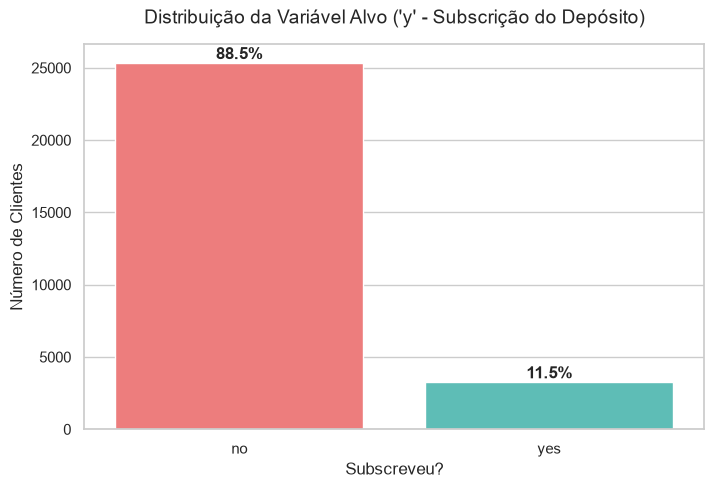

Conclusão: A taxa de conversão padrão ronda os 11%. Uma plataforma MAB é mandatória para otimizar este cenário.


In [2]:
target_counts = df["y"].value_counts()
target_percentages = df["y"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    ax=ax,
    hue=target_counts.index,
    palette=["#FF6B6B", "#4ECDC4"],
    legend=False,
)

ax.set_title(
    "Distribuição da Variável Alvo ('y' - Subscrição do Depósito)", fontsize=14, pad=15
)
ax.set_ylabel("Número de Clientes")
ax.set_xlabel("Subscreveu?")

for i, p in enumerate(ax.patches):
    ax.annotate(
        f"{target_percentages.iloc[i]:.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

plt.show()

print(
    "Conclusão: A taxa de conversão padrão ronda os 11%. Uma plataforma MAB é mandatória para otimizar este cenário."
)

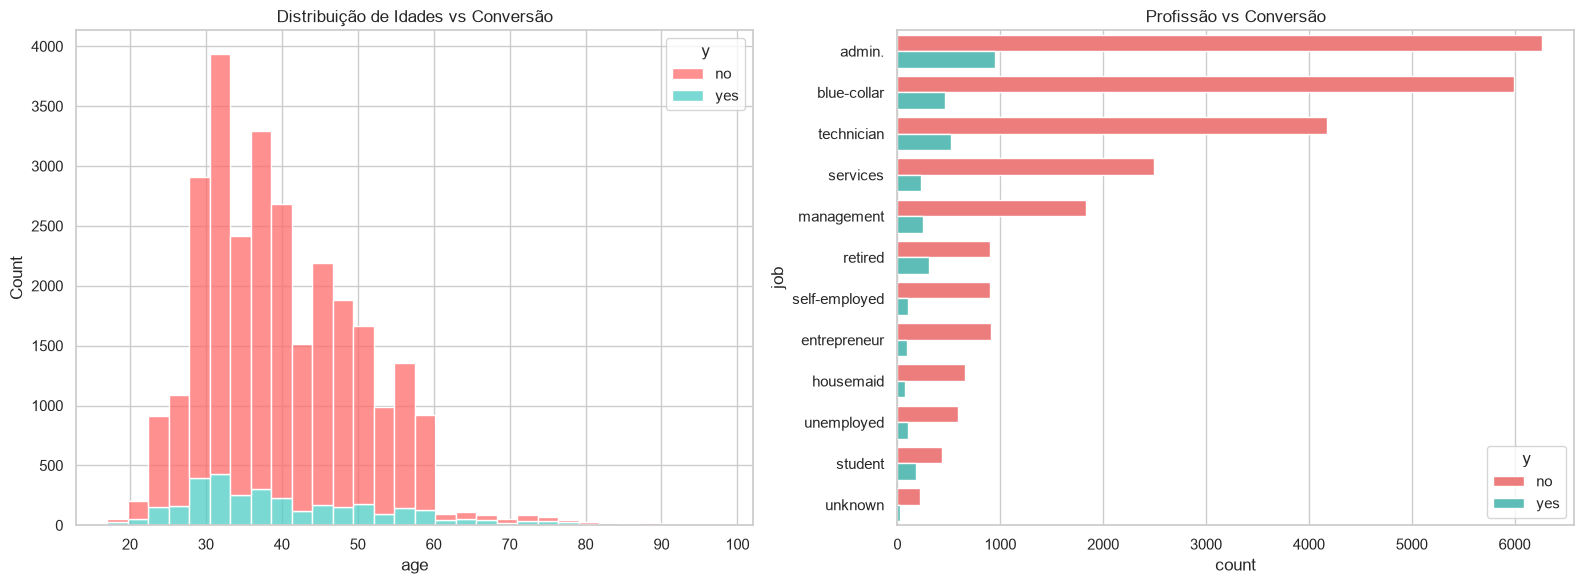

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    data=df,
    x="age",
    hue="y",
    bins=30,
    multiple="stack",
    ax=axes[0],
    palette=["#FF6B6B", "#4ECDC4"],
)
axes[0].set_title("Distribuição de Idades vs Conversão")

job_order = df["job"].value_counts().index
sns.countplot(
    data=df,
    y="job",
    hue="y",
    order=job_order,
    ax=axes[1],
    palette=["#FF6B6B", "#4ECDC4"],
)
axes[1].set_title("Profissão vs Conversão")

plt.tight_layout()
plt.show()

## Baseline vs Thompson Sampling

O baseline sempre escolhe a oferta com maior conversão histórica registrada. Se a taxa histórica ainda reflete a realidade, isso funciona. Se não reflete, ele fica preso no passado.

Pra deixar a diferença visível, simulamos um cenário de drift: `loan_payroll` era o campeão histórico (2,9%), mas `savings_premium` passou a converter 4,5% na prática. O baseline continua fiel ao histórico, enquanto o Thompson explora e migra pro braço que realmente performa. Rodamos 500 rodadas com esse setup e comparamos as duas políticas lado a lado.


In [4]:
import sys
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.api.schemas import CustomerContext
from src.evaluation.bandit_benchmark import BanditScenario, compare_bandit_policies

N_ROUNDS = 500

scenarios = [
    BanditScenario(
        context=CustomerContext(customer_id=f"S{i:04d}", age=35),
        candidate_offers=[
            "loan_personal",
            "loan_payroll",
            "credit_card_gold",
            "savings_premium",
        ],
        true_conversion_by_offer={
            "loan_personal": 0.014,
            "loan_payroll": 0.020,
            "credit_card_gold": 0.011,
            "savings_premium": 0.045,
        },
    )
    for i in range(N_ROUNDS)
]

result = compare_bandit_policies(scenarios, seed=75)

summary = pd.DataFrame(
    [
        {"Política": "Baseline determinístico", **result["baseline"].to_dict()},
        {"Política": "Thompson Sampling", **result["adaptive"].to_dict()},
    ]
).drop(columns=["policy_version"])

summary


,Política,total_rounds,total_reward,total_regret,avg_regret,conversion_rate,exploration_rate,cold_start_rate,avg_reward_delay_days,delayed_reward_rate
0,Baseline determinístico,500,13.0,12.500,0.025000,0.026,0.00,0.000,0.0,0.0
1,Thompson Sampling,500,15.0,8.252,0.016504,0.030,0.58,0.132,0.0,0.0


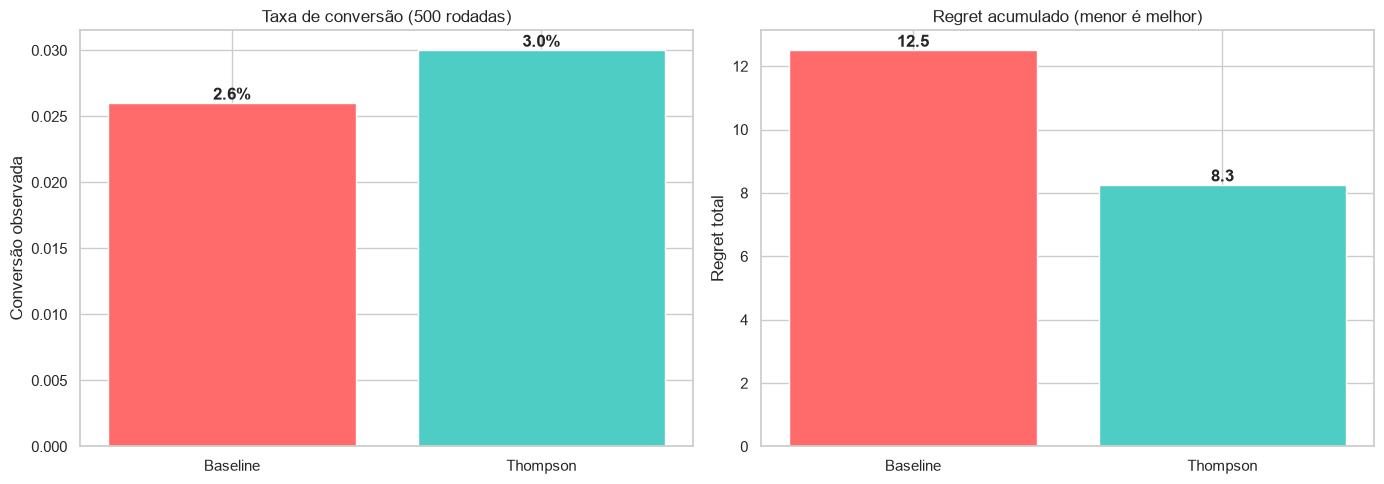

Ganho do Thompson vs Baseline em conversão: +0.4%
Regret evitado pelo Thompson: +4.25


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

policies = ["Baseline", "Thompson"]
conversion_rates = [
    result["baseline"].conversion_rate,
    result["adaptive"].conversion_rate,
]
regrets = [result["baseline"].total_regret, result["adaptive"].total_regret]

bars1 = axes[0].bar(policies, conversion_rates, color=["#FF6B6B", "#4ECDC4"])
axes[0].set_title(f"Taxa de conversão ({N_ROUNDS} rodadas)")
axes[0].set_ylabel("Conversão observada")
for bar, value in zip(bars1, conversion_rates):
    axes[0].annotate(
        f"{value:.1%}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

bars2 = axes[1].bar(policies, regrets, color=["#FF6B6B", "#4ECDC4"])
axes[1].set_title("Regret acumulado (menor é melhor)")
axes[1].set_ylabel("Regret total")
for bar, value in zip(bars2, regrets):
    axes[1].annotate(
        f"{value:.1f}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

print(
    "Ganho do Thompson vs Baseline em conversão: "
    f"{result['delta']['conversion_rate']:+.1%}"
)
print(
    "Regret evitado pelo Thompson: "
    f"{result['delta']['regret']:+.2f}"
)


## Casos de teste do golden set

Cinco perfis representativos tirados de `data/golden_set/evaluation_cases.jsonl`. Cada linha da tabela mostra a oferta que a gente esperava, o que o baseline escolheu e o que o Thompson escolheu partindo do cold start. Serve pra checar se as decisões fazem sentido em casos isolados — o baseline tende a acertar mais quando o histórico bate com o segmento, o Thompson depende de aquecimento pra convergir.


In [6]:
import json

from src.evaluation.bandit_benchmark import (
    DeterministicBaselinePolicy,
    ThompsonSamplingPolicy,
)

GOLDEN_SET = REPO_ROOT / "data" / "golden_set" / "evaluation_cases.jsonl"

cases = []
with open(GOLDEN_SET, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        cases.append(json.loads(line))
        if len(cases) == 5:
            break

baseline = DeterministicBaselinePolicy()
all_arms = list({o for c in cases for o in c["candidate_offers"]})
thompson = ThompsonSamplingPolicy(arms=all_arms, seed=75)

rows = []
for case in cases:
    ctx = CustomerContext(**case["context"])
    b_chosen, _ = baseline.recommend(ctx, candidates=case["candidate_offers"])
    t_chosen, _ = thompson.recommend(ctx, candidates=case["candidate_offers"])
    rows.append(
        {
            "case_id": case["case_id"],
            "segmento": case["segment"],
            "idade": ctx.age,
            "saldo": ctx.balance,
            "esperado": case["expected_action"],
            "baseline": b_chosen.offer_id,
            "thompson": t_chosen.offer_id,
            "baseline_ok": b_chosen.offer_id == case["expected_action"],
            "thompson_ok": t_chosen.offer_id == case["expected_action"],
        }
    )

pd.DataFrame(rows)


,case_id,segmento,idade,saldo,esperado,baseline,thompson,baseline_ok,thompson_ok
0,case_01_senior_affluent,senior_affluent,67,8200.0,loan_payroll,loan_payroll,loan_payroll,True,True
1,case_02_senior_saver,senior_saver,64,1200.0,savings_premium,savings_premium,savings_premium,True,True
2,case_03_young_student,young_student,23,150.0,credit_card_gold,credit_card_gold,insurance_basic,True,False
3,case_04_prime_homeowner,prime_homeowner,41,6400.0,loan_payroll,loan_payroll,loan_personal,True,False
4,case_05_prime_low_balance,prime_low_balance,38,420.0,credit_card_gold,credit_card_gold,insurance_basic,True,False
